<img src="./mse_logo.png" width="340" align="right"/>
<div style="text-align: left"> <b> Machine Learning </b> <br> MSE FTP MachLe <br> 
<a href="mailto:christoph.wuersch@ost.ch"> Christoph Würsch </a> </div>

# Group 1: Feature Normalization
## (i) Why Normalization Matters

In machine learning, datasets often contain features that vary wildly in magnitudes, units, and ranges. For example, a dataset predicting house prices might include the number of bedrooms (ranging from 1 to 5) and the total square footage (ranging from 500 to 5,000).

**Feature normalization** (or scaling) is the process of adjusting the values measured on different scales to a common scale. But why is this necessary?

If we leave features unscaled, the machine learning model can become biased toward features with higher magnitudes, leading to poor performance, slow training times, or completely inaccurate predictions.

The load_wine dataset is a good built-in dataset to demonstrate this concept. It contains 13 features, but their scales are drastically different. For example, the proline feature ranges from ~270 to 1680, while nonflavanoid_phenols ranges from ~0.1 to 0.6.

If we use Principal Component Analysis (PCA) to reduce this data to 2 dimensions for visualization, an unscaled PCA will just follow the proline feature because it has the largest numbers (and thus the largest mathematical variance). When we scale it, the true structure of the three wine classes emerges.

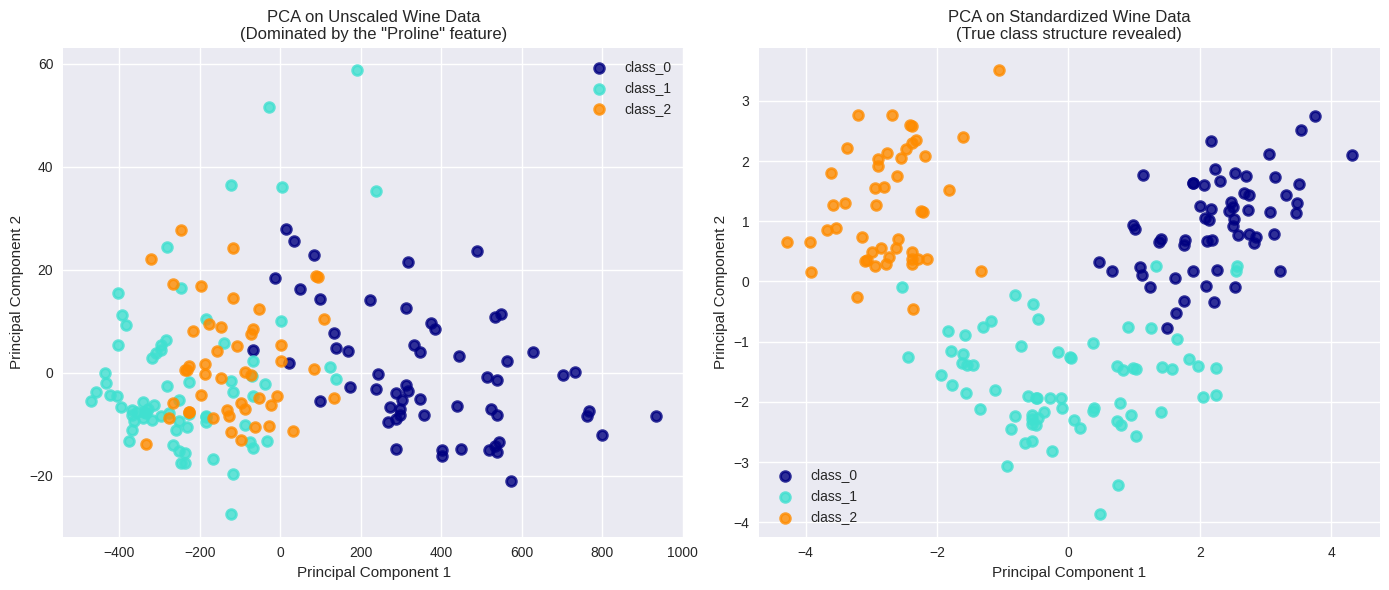

Variance explained by PC1 (Unscaled): 99.81%
Variance explained by PC1 (Scaled):   36.20%


In [10]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load the Wine Dataset
wine = load_wine()
X = wine.data
y = wine.target
target_names = wine.target_names

# 2. Perform PCA WITHOUT scaling
pca_unscaled = PCA(n_components=2)
X_unscaled_pca = pca_unscaled.fit_transform(X)

# 3. Perform PCA WITH scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_scaled = PCA(n_components=2)
X_scaled_pca = pca_scaled.fit_transform(X_scaled)

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = ['navy', 'turquoise', 'darkorange']

# Plot 1: Unscaled PCA
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    ax1.scatter(X_unscaled_pca[y == i, 0], X_unscaled_pca[y == i, 1],
                color=color, alpha=0.8, lw=2, label=target_name)
ax1.set_title('PCA on Unscaled Wine Data\n(Dominated by the "Proline" feature)')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.legend(loc='best', shadow=False, scatterpoints=1)

# Plot 2: Scaled PCA
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    ax2.scatter(X_scaled_pca[y == i, 0], X_scaled_pca[y == i, 1],
                color=color, alpha=0.8, lw=2, label=target_name)
ax2.set_title('PCA on Standardized Wine Data\n(True class structure revealed)')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.legend(loc='best', shadow=False, scatterpoints=1)

plt.tight_layout()
plt.show()

print("Variance explained by PC1 (Unscaled):", f"{pca_unscaled.explained_variance_ratio_[0]*100:.2f}%")
print("Variance explained by PC1 (Scaled):  ", f"{pca_scaled.explained_variance_ratio_[0]*100:.2f}%")

---
## (ii) Which learners depend on feature normalization?

### Overview

| Learner | Depends on normalization? | Reason |
|---|---|---|
| **k-Nearest Neighbors (kNN)** | **Yes** | Distance-based |
| **Support Vector Machines (SVM)** | **Yes** | Dot-product / distance-based + regularization |
| **Linear models (Linear / Logistic Regression)** | **Yes** (with regularization) | Regularization penalizes coefficients equally |
| **Neural Networks** | **Yes** | Gradient-based optimization is scale-sensitive |
| Decision Trees / Random Forests | No | Split criteria are per-feature thresholds |
| Gradient-Boosted Trees (XGBoost, etc.) | No | Also threshold-based splits |

The key insight: any algorithm that uses **distances, dot products, or gradient descent** is sensitive to feature scales.

### 1. k-Nearest Neighbors (kNN)

kNN classifies a sample by finding the **k closest training points** (usually via Euclidean distance):

$$d(\mathbf{x}, \mathbf{x}') = \sqrt{\sum_{j=1}^{p}(x_j - x'_j)^2}$$

If one feature has a range of 0–200 000 while another ranges 0–1, the distance is
almost entirely determined by the first feature. Normalization ensures **every feature
contributes proportionally** to the distance.

kNN without normalization: 0.691 ± 0.049
kNN with standardization:  0.949 ± 0.038


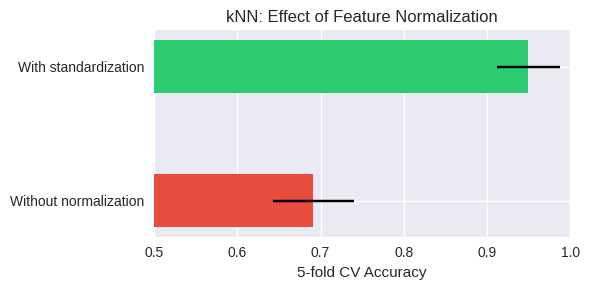

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

X, y = load_wine(return_X_y=True)

# kNN WITHOUT normalization
knn_raw = KNeighborsClassifier(n_neighbors=5)
scores_raw = cross_val_score(knn_raw, X, y, cv=5, scoring="accuracy")

# kNN WITH standardization
knn_scaled = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
scores_scaled = cross_val_score(knn_scaled, X, y, cv=5, scoring="accuracy")

print(f"kNN without normalization: {scores_raw.mean():.3f} ± {scores_raw.std():.3f}")
print(f"kNN with standardization:  {scores_scaled.mean():.3f} ± {scores_scaled.std():.3f}")

# Visualize
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(["Without normalization", "With standardization"],
        [scores_raw.mean(), scores_scaled.mean()],
        xerr=[scores_raw.std(), scores_scaled.std()],
        color=["#e74c3c", "#2ecc71"], height=0.4)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("5-fold CV Accuracy")
ax.set_title("kNN: Effect of Feature Normalization")
plt.tight_layout()
plt.show()

---
### Key Takeaways

1. **Always normalize** when using distance-based (kNN), kernel-based (SVM), regularized linear,
   or gradient-descent-based (neural network) models.
2. **Tree-based models** (Decision Trees, Random Forests, Gradient-Boosted Trees) are
   **not affected** because they use per-feature threshold splits.
3. **Standardization (Z-score)** is the most common default. Use **Min-Max** when you need
   bounded outputs (e.g. image pixels) and **Robust Scaling** when outliers are present.
4. Always fit the scaler on the **training set only** and transform the test set with the
   same parameters — using `sklearn.pipeline.make_pipeline` handles this automatically
   inside cross-validation.

| Ask yourself | If yes → |
|---|---|
| Does the algorithm use distances or dot products? | Normalize |
| Does the algorithm use gradient descent? | Normalize |
| Does the algorithm use regularization? | Normalize |
| Is it a tree-based model? | No normalization needed |

## (iii) Standard Scaling (Z-Transform)

**Purpose:**
Standard scaling normalizes features so they have **mean 0** and **standard deviation 1**, making them comparable and improving ML model performance.

**Formula:**

$$
x_{\text{scaled}} = \frac{x - \mu}{\sigma}
$$

Where:
- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

**Why use it:**
- Centers data around 0 → faster convergence for gradient-based algorithms
- Unit variance → avoids dominance of large-scale features
- Better for distance-based models (KNN, clustering, SVM)

**Notes:**
- Does **not bound** values between 0 and 1
- Sensitive to outliers; for strong outliers, consider **robust scaling**

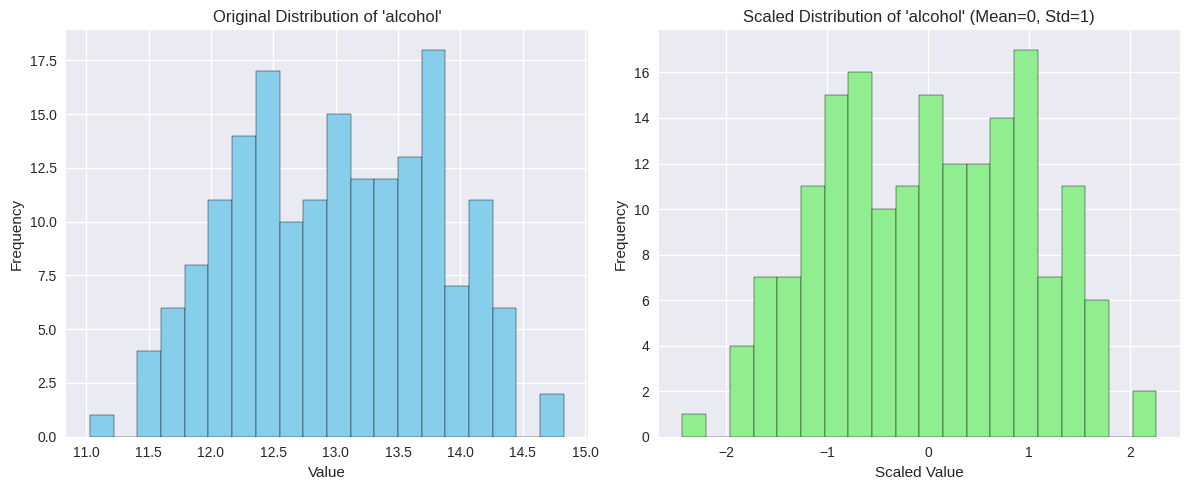

Original mean: 13.001, std: 0.810
Scaled mean: -0.000, std: 1.000


In [12]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

# Load the Wine dataset
wine = load_wine(as_frame=True)  # returns pandas DataFrame
X = wine.data  # shape (178, 13)
feature = "alcohol"

# Extract the chosen feature
data_orig = X[feature].values.reshape(-1, 1)

# Apply Standard Scaling
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_orig).flatten()

# Plot histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(data_orig, bins=20, color="skyblue", edgecolor="black")
axes[0].set_title(f"Original Distribution of '{feature}'")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")
axes[0].grid(True)

axes[1].hist(data_scaled, bins=20, color="lightgreen", edgecolor="black")
axes[1].set_title(f"Scaled Distribution of '{feature}' (Mean=0, Std=1)")
axes[1].set_xlabel("Scaled Value")
axes[1].set_ylabel("Frequency")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Original mean: {data_orig.mean():.3f}, std: {data_orig.std():.3f}")
print(f"Scaled mean: {data_scaled.mean():.3f}, std: {data_scaled.std():.3f}")

## (iv) Min-Max Scaling

The aim of min-max scaling is to create a uniform range for the feature (typically between 0 and 1) whilst still maintaining the original distribution shape.

The scaling can be applied by using the following formula:

$$X_{scaled} = \frac{X_i - X_{min}}{X_{max} - X_{min}}$$

**Where:**
* $X_i$ = original value
* $X_{min}$ = minimum value of the feature
* $X_{max}$ = maximum value of the feature

> **Main Drawback:** As the name suggests, this method relies strictly on the maximum and minimum values, making it highly sensitive to **outliers**. A single massive outlier will squash the rest of the normal data into a tiny sliver of the scaled range.

Let's now look at an example showcasing this sensitivity using the `sklearn` wine dataset:

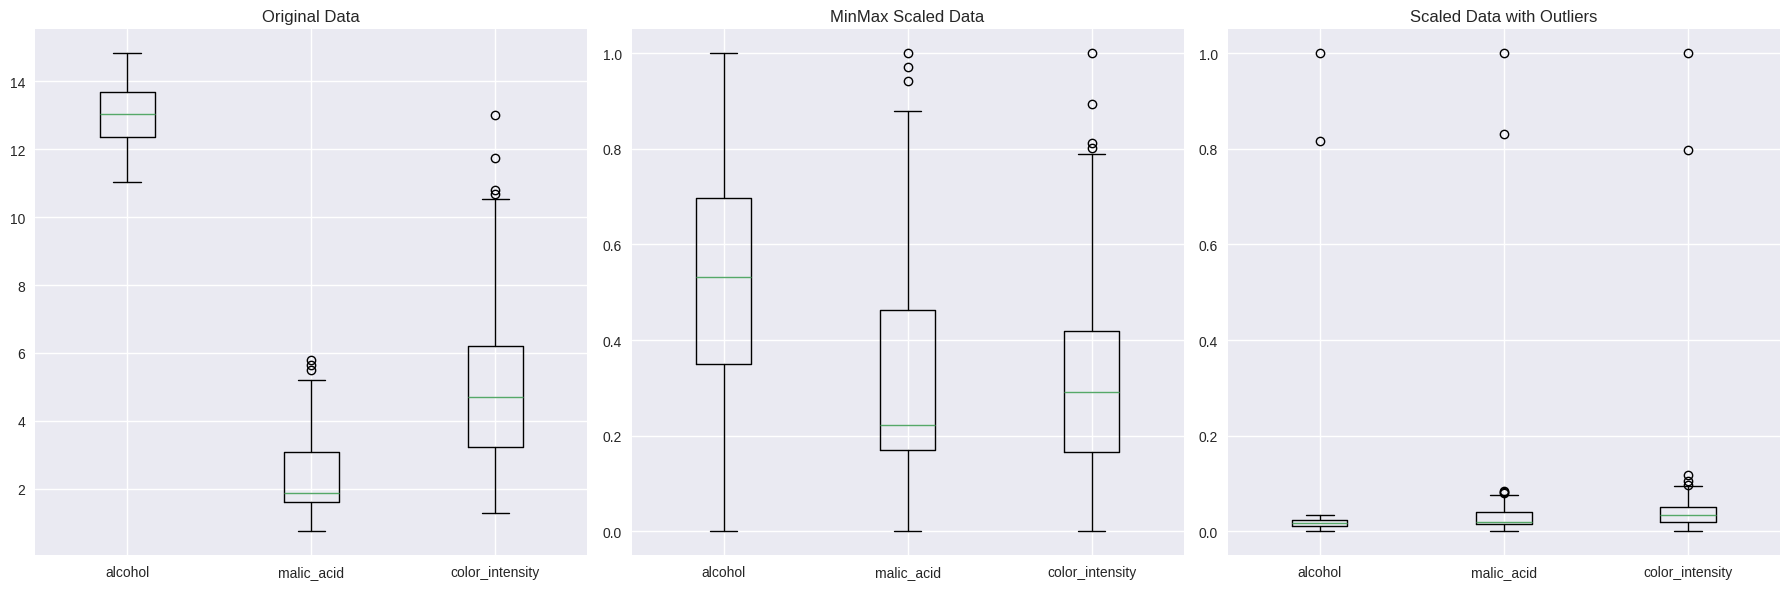

Created visualization of original, scaled, and outlier-sensitive data distributions


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler

wine = load_wine(as_frame=True)
df = wine.frame[['alcohol', 'malic_acid', 'color_intensity']]

scaler = MinMaxScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Create a copy and add artificial outliers
df_with_outliers = df.copy()
df_with_outliers.loc[len(df)] = [100, 50, 80]  # extreme outlier values
df_with_outliers.loc[len(df)+1] = [120, 60, 100]

# Re-scale after adding outliers
scaled_with_outliers = pd.DataFrame(scaler.fit_transform(df_with_outliers), columns=df.columns)

# Plotting
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original data
axes[0].boxplot(df.values, tick_labels=df.columns)
axes[0].set_title("Original Data")

# Scaled data
axes[1].boxplot(scaled_df.values, tick_labels=scaled_df.columns)
axes[1].set_title("MinMax Scaled Data")

# Scaled data with outliers
axes[2].boxplot(scaled_with_outliers.values, tick_labels=scaled_with_outliers.columns)
axes[2].set_title("Scaled Data with Outliers")

for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.show()

print("Created visualization of original, scaled, and outlier-sensitive data distributions")


## (v) Robust Scaling (median and IQR)

Used against outliers
* Outliers: Data which is far off the usual distribution.
* [3000, 3200, 3100, 3050, 100000]

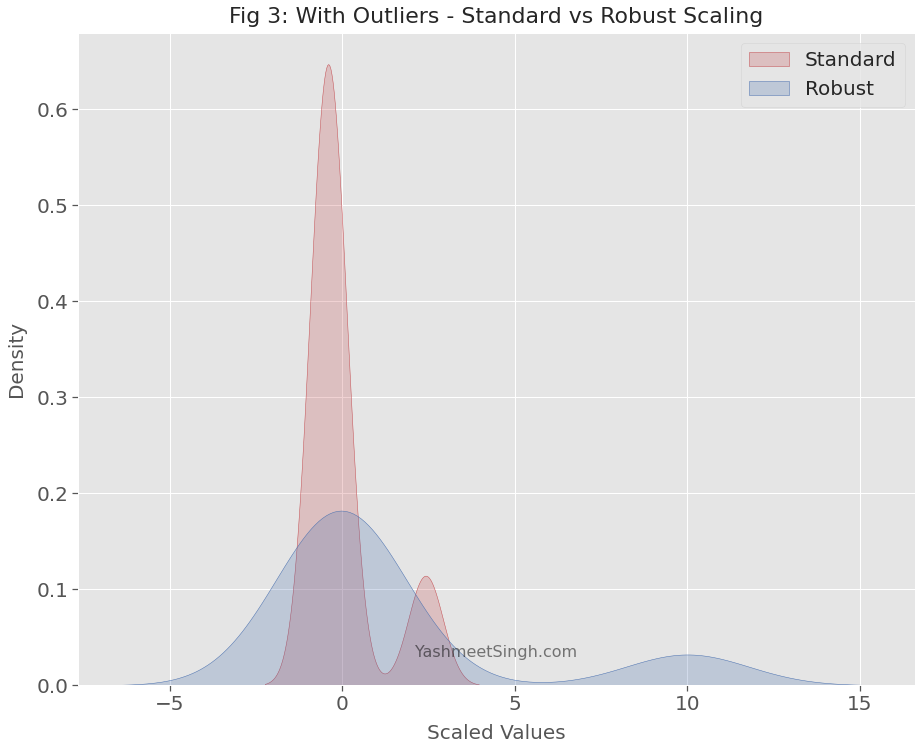

Source: https://proclusacademy.com/images/004_3_std_vs_robust.png



Formula IQR:

### Interquartile Range (IQR)



The interquartile range is defined as:

\[
IQR = Q_3 - Q_1
\]

where:

- \(Q_1\) = first quartile (25th percentile)
- \(Q_3\) = third quartile (75th percentile)

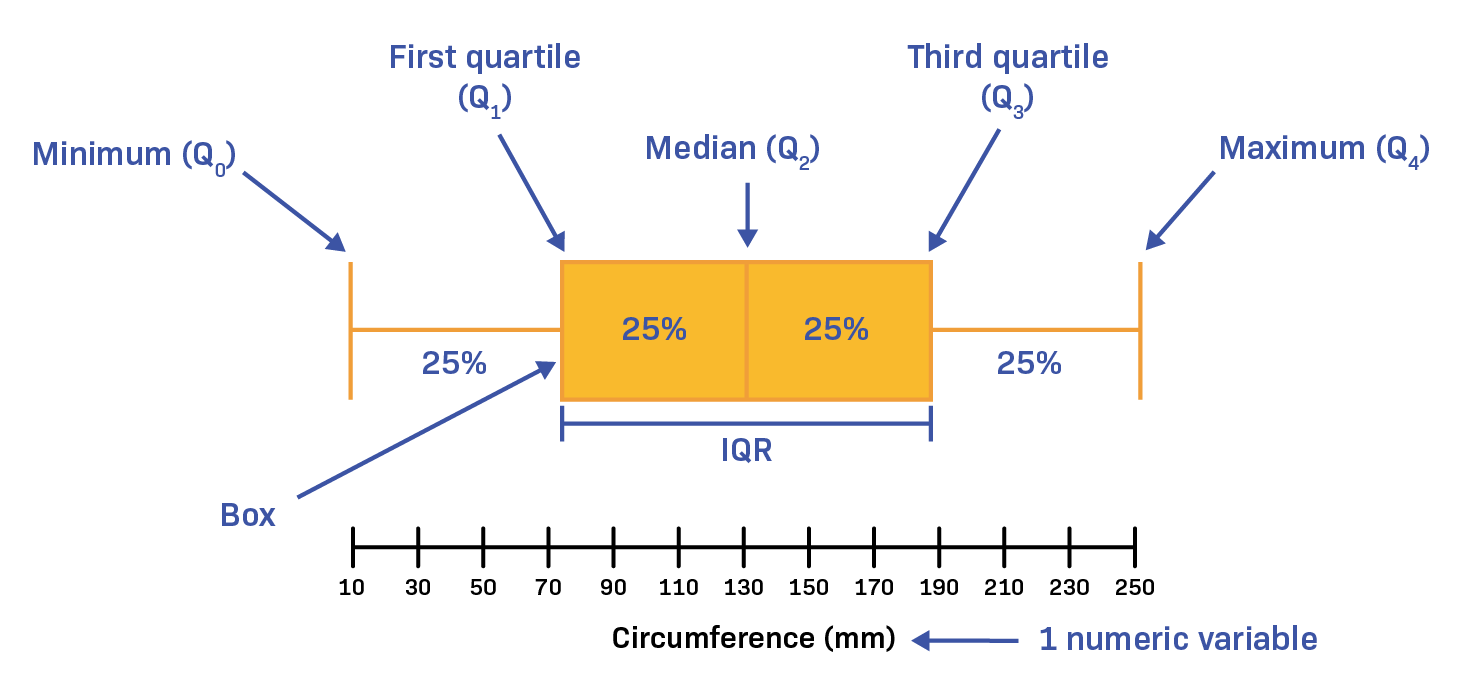
Source: https://api.www.labxchange.org/api/v1/xblocks/lb%3ALabXchange%3Ad8863c77%3Ahtml%3A1/storage/211626365402575-b88c4d0fdacd5abb4c3dc2de3bc004bb.png

In [14]:
#Sample Code:
import numpy as np

def robust_scale(X):
    """
    Apply Robust Scaling using median and IQR.

    Parameters
    ----------
    X : numpy array (n_samples, n_features)

    Returns
    -------
    X_scaled : scaled array
    """

    median = np.median(X, axis=0)
    q1 = np.percentile(X, 25, axis=0)
    q3 = np.percentile(X, 75, axis=0)

    iqr = q3 - q1

    # Avoid division by zero
    iqr[iqr == 0] = 1

    X_scaled = (X - median) / iqr

    return X_scaled

    X = np.array([
    [1, 10],
    [2, 12],
    [3, 14],
    [4, 16],
    [100, 200]
])

X_scaled = robust_scale(X)
print(X_scaled)

      alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0    0.897338   -0.104730  0.201439          -0.906977   1.526316   
1    0.114068   -0.057432 -0.633094          -1.930233   0.105263   
2    0.083650    0.334459  0.892086          -0.209302   0.157895   
3    1.003802    0.057432  0.402878          -0.627907   0.789474   
4    0.144487    0.489865  1.467626           0.348837   1.052632   
..        ...         ...       ...                ...        ...   
173  0.501901    2.557432  0.258993           0.232558  -0.157895   
174  0.266160    1.381757  0.345324           0.813953   0.210526   
175  0.167300    1.631757 -0.287770           0.116279   1.157895   
176  0.091255    0.489865  0.028777           0.116279   1.157895   
177  0.821293    1.510135  1.093525           1.162791  -0.105263   

     total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0         0.420804    0.553892             -0.358209         1.050000   
1         0.278960    0.3

## (vi) Skewness and power transforms:

Power transforms are techniques used to stabilize variance and make the data more normal distribution-like (Gaussian). This is particularly useful for dealing with skewed data.

### Box–Cox

The Box-Cox transformation is a family of power transformations indexed by a parameter $\lambda$.

$$y(\lambda) = \begin{cases} \frac{y^\lambda - 1}{\lambda}, & \lambda \neq 0 \\ \ln(y), & \lambda = 0 \end{cases}$$

**Variables:**
* **y**: Positive data
* **$\lambda$**: Power parameter controlling normalization

**Limitations:**
* Only works for **positive data**; zeros or negatives must be shifted (e.g., by adding a constant).
* Does **not guarantee perfect normality**.
* Changes the scale of the data, reducing interpretability unless reversed.

---

### Yeo–Johnson

The Yeo-Johnson transformation is an extension of the Box-Cox transformation that handles both positive and negative values without requiring a shift.

$$y(\lambda) = \begin{cases} \frac{(y+1)^\lambda - 1}{\lambda}, & \text{if } y \ge 0, \lambda \neq 0 \\ \ln(y+1), & \text{if } y \ge 0, \lambda = 0 \\ -\frac{(1-y)^{(2-\lambda)} - 1}{2-\lambda}, & \text{if } y < 0, \lambda \neq 2 \\ -\ln(1-y), & \text{if } y < 0, \lambda = 2 \end{cases}$$

**Variables:**
* **y**: Any real value
* **$\lambda$**: Power parameter controlling normalization

**Limitations:**
* Assumes a **monotonic transformation**, which may not help for non-monotonic patterns.
* Estimation of $\lambda$ can be **unstable** for small samples or heavy-tailed distributions.
* More **computationally expensive** than fixed transformations.

---
## (vii) Outlook for Neural Networks: Vanishing and Exploding Gradients

Neural networks learn by **backpropagation**: the loss gradient is propagated backwards through the network using the **chain rule**. For a network with $L$ layers, the gradient of the loss $\mathcal{L}$ with respect to the weights $W^{(l)}$ in layer $l$ involves a product of partial derivatives across all subsequent layers:

$$
\frac{\partial \mathcal{L}}{\partial W^{(l)}} = \frac{\partial \mathcal{L}}{\partial a^{(L)}} \cdot \prod_{k=l+1}^{L} \frac{\partial a^{(k)}}{\partial a^{(k-1)}} \cdot \frac{\partial a^{(l)}}{\partial W^{(l)}}
$$

where $a^{(k)}$ is the activation of layer $k$. The critical term is the **product of Jacobians** $\prod \frac{\partial a^{(k)}}{\partial a^{(k-1)}}$, which includes the derivatives of the activation functions and the weight matrices.

### Vanishing Gradients

If the factors in this product are consistently **less than 1** (e.g. the maximum derivative of sigmoid is only 0.25), the gradient **shrinks exponentially** with depth:

$$\text{gradient} \approx (0.25)^L \to 0 \quad \text{as } L \to \infty$$

Early layers receive near-zero gradients and effectively **stop learning**. This was the main reason deep networks were considered untrainable before ~2010.

### Exploding Gradients

Conversely, if the factors are consistently **greater than 1** (e.g. large weight values), the gradient **grows exponentially**:

$$\text{gradient} \approx c^L \to \infty \quad \text{for } c > 1$$

This leads to enormous weight updates, numerical overflow (`NaN` losses), and **unstable training**.

### Why activation functions matter

| Activation | Derivative range | Gradient behaviour in deep nets |
|---|---|---|
| **Sigmoid** $\sigma(x)$ | $(0,\; 0.25]$ | Vanishes (factors always < 1) |
| **Tanh** | $(0,\; 1]$ | Better, but still vanishes for saturated inputs |
| **ReLU** $\max(0, x)$ | $\{0,\; 1\}$ | No shrinkage for active neurons (gradient = 1) |

ReLU largely solved the vanishing gradient problem for feed-forward networks because its derivative is exactly **1** for positive inputs, allowing gradients to flow unchanged.

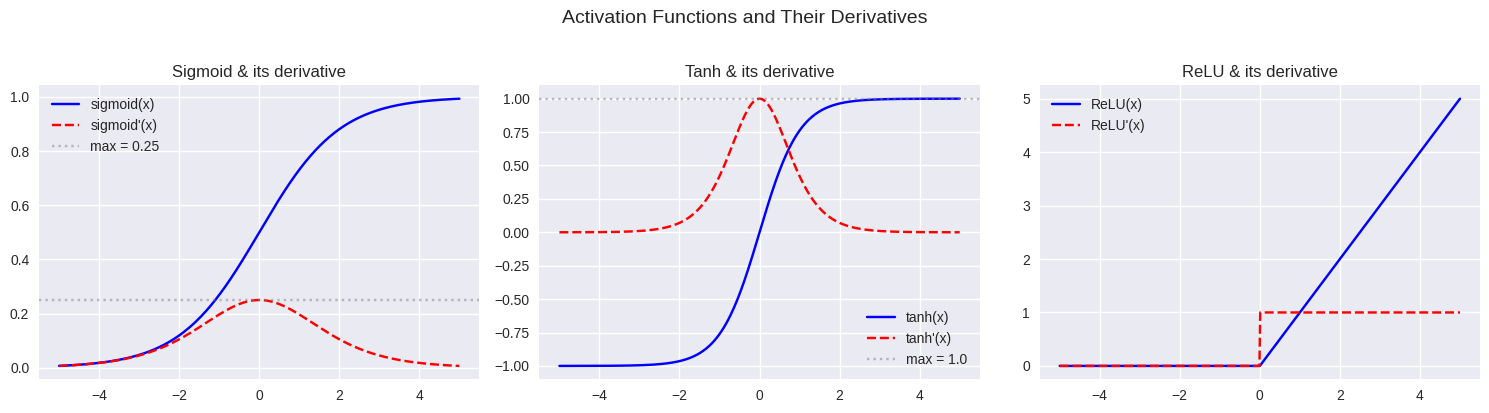

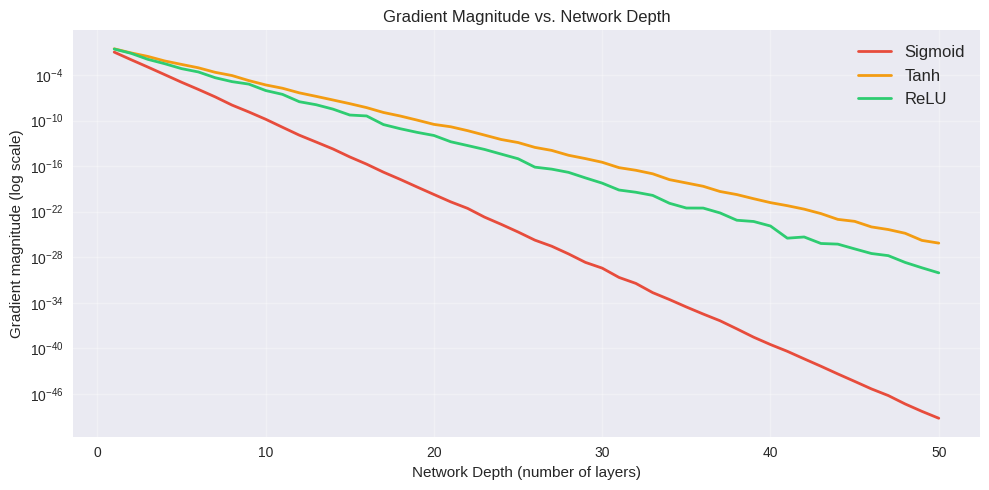

Gradient at layer 1 after passing through 50 layers:
  Sigmoid : 5.96e-50
  Tanh    : 7.16e-27
  ReLU    : 8.61e-31


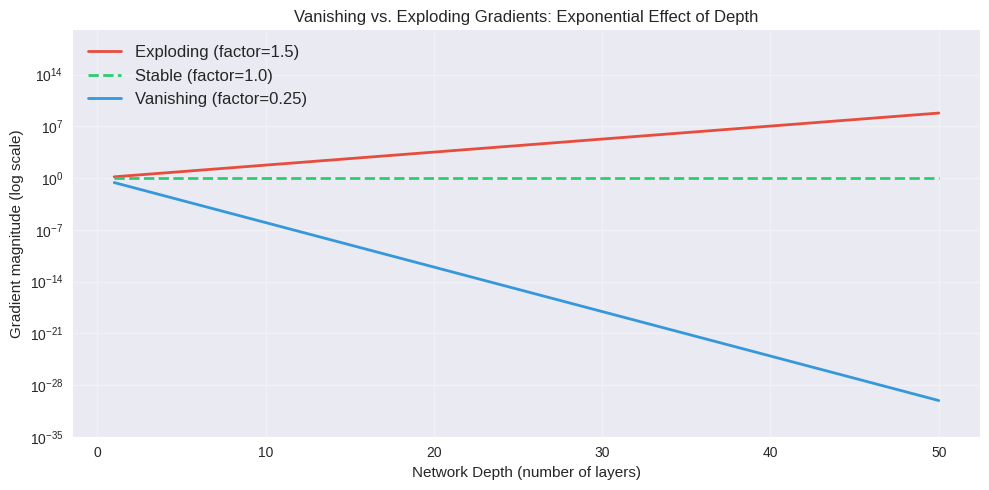

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Activation functions and their derivatives ---
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh_deriv(x):
    return 1 - np.tanh(x) ** 2

def relu_deriv(x):
    return (x > 0).astype(float)

# Plot activation derivatives
x = np.linspace(-5, 5, 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(x, sigmoid(x), label="sigmoid(x)", color="blue")
axes[0].plot(x, sigmoid_deriv(x), label="sigmoid'(x)", color="red", linestyle="--")
axes[0].axhline(0.25, color="gray", linestyle=":", alpha=0.5, label="max = 0.25")
axes[0].set_title("Sigmoid & its derivative")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(x, np.tanh(x), label="tanh(x)", color="blue")
axes[1].plot(x, tanh_deriv(x), label="tanh'(x)", color="red", linestyle="--")
axes[1].axhline(1.0, color="gray", linestyle=":", alpha=0.5, label="max = 1.0")
axes[1].set_title("Tanh & its derivative")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(x, np.maximum(0, x), label="ReLU(x)", color="blue")
axes[2].plot(x, relu_deriv(x), label="ReLU'(x)", color="red", linestyle="--")
axes[2].set_title("ReLU & its derivative")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("Activation Functions and Their Derivatives", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- 2. Simulate gradient flow through a deep network ---
np.random.seed(42)
depths = range(1, 51)

gradient_norms = {"Sigmoid": [], "Tanh": [], "ReLU": []}
activations = {"Sigmoid": sigmoid_deriv, "Tanh": tanh_deriv, "ReLU": relu_deriv}

for name, deriv_fn in activations.items():
    for depth in depths:
        grad = 1.0
        for _ in range(depth):
            # Simulate pre-activations drawn from N(0, 1)
            z = np.random.randn(100)
            # Average derivative at this layer
            avg_deriv = np.mean(deriv_fn(z))
            # Weight factor (mean absolute weight ~ 0.5 for illustration)
            grad *= avg_deriv * 0.5
        gradient_norms[name].append(abs(grad))

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(list(depths), gradient_norms["Sigmoid"], label="Sigmoid", color="#e74c3c", linewidth=2)
ax.semilogy(list(depths), gradient_norms["Tanh"], label="Tanh", color="#f39c12", linewidth=2)
ax.semilogy(list(depths), gradient_norms["ReLU"], label="ReLU", color="#2ecc71", linewidth=2)
ax.set_xlabel("Network Depth (number of layers)")
ax.set_ylabel("Gradient magnitude (log scale)")
ax.set_title("Gradient Magnitude vs. Network Depth")
ax.legend(fontsize=12)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print("Gradient at layer 1 after passing through 50 layers:")
for name in gradient_norms:
    print(f"  {name:8s}: {gradient_norms[name][-1]:.2e}")

# --- 3. Exploding gradients demonstration ---
fig, ax = plt.subplots(figsize=(10, 5))
exploding = [1.5 ** d for d in depths]   # factor > 1 each layer
stable    = [1.0 ** d for d in depths]    # factor = 1 (ideal)
vanishing = [0.25 ** d for d in depths]   # factor < 1 (sigmoid worst case)

ax.semilogy(list(depths), exploding, label="Exploding (factor=1.5)", color="#e74c3c", linewidth=2)
ax.semilogy(list(depths), stable, label="Stable (factor=1.0)", color="#2ecc71", linewidth=2, linestyle="--")
ax.semilogy(list(depths), vanishing, label="Vanishing (factor=0.25)", color="#3498db", linewidth=2)
ax.set_xlabel("Network Depth (number of layers)")
ax.set_ylabel("Gradient magnitude (log scale)")
ax.set_title("Vanishing vs. Exploding Gradients: Exponential Effect of Depth")
ax.legend(fontsize=12)
ax.grid(True, which="both", alpha=0.3)
ax.set_ylim(1e-35, 1e20)
plt.tight_layout()
plt.show()

### Common Solutions

| Problem | Solution | How it helps |
|---|---|---|
| **Vanishing gradients** | Use **ReLU** (or Leaky ReLU, ELU) instead of sigmoid/tanh | Derivative is 1 for positive inputs — no shrinkage |
| **Vanishing gradients** | **Batch Normalization** | Re-centers activations each layer, keeps gradients well-scaled |
| **Vanishing gradients** | **Residual connections** (ResNets) | Skip connections let gradients bypass layers: $\nabla = 1 + \ldots$ |
| **Exploding gradients** | **Gradient clipping** | Caps the gradient norm to a maximum value |
| **Both** | **Proper weight initialization** (Xavier / He) | Sets initial weight variance so signals neither grow nor shrink |

### Connection to Feature Normalization

This ties directly back to our topic: **input normalization** is the _first line of defence_ against gradient instability. If feature scales are wildly different, the initial activations are skewed, and the gradient problems above are amplified from the very first layer. Standardizing inputs ensures the network starts in a well-conditioned region of its loss landscape.

### Key Takeaways

1. **Vanishing gradients** cause early layers to stop learning — this was the main roadblock for deep learning until ReLU and batch normalization.
2. **Exploding gradients** cause training instability — mitigated by gradient clipping and careful initialization.
3. Both problems grow **exponentially** with network depth, which is why they only became critical as networks went from 2–3 layers to dozens or hundreds.
4. Modern architectures (ResNets, Transformers) combine **ReLU-family activations, skip connections, layer normalization, and proper initialization** to train networks with hundreds of layers stably.
5. **Normalizing your input features** (the topic of this notebook) is a prerequisite — without it, even these modern techniques struggle.

## Takeaways for Feature Normalization

**What every ML practitioner should remember:**
1. **Normalize to compare features:** Features with different scales or units can dominate algorithms if not normalized.
2. **Choose the right method:** Standard scaling, min-max, robust scaling, or power transforms depend on the data distribution and model requirements.
3. **Centering and variance matter:** Standardization (mean=0, std=1) helps gradient-based algorithms converge faster.
4. **Consider skewness:** Non-normal distributions may benefit from transformations like Yeo‑Johnson or Box‑Cox.

**Common Pitfalls:**
1. **Sensitivity to outliers:** Standard scaling is affected by extreme values — robust scaling may be better.
2. **Ignoring distribution:** Min-max scaling or standardization assumes roughly similar ranges; skewed data may need power transforms.
3. **Feature dependence:** Always scale features individually; combining them or scaling the target can cause problems.
4. **Leaking information:** Fit scalers only on training data, then apply to test data to avoid data leakage.

**When does normalization really matter?**
1. **Always for algorithms sensitive to feature scale:** Gradient descent (linear/logistic regression, neural networks), distance-based methods (KNN, SVM, clustering).
2. **Optional for tree-based models:** Decision trees, random forests, or gradient boosting are mostly scale-invariant.
3. **Critical for visualization and PCA:** Features must be comparable to interpret patterns or principal components correctly.

## Authors:
- Jasper van Renssen
- Roland Roccaro
- Pascal Gesell
- Linda Dutler
- Patrick Rossacher